# Ookla Cross-Country Comparison — Thailand vs Vietnam / Philippines / Singapore

Compares broadband quality across the four SEA countries covered by the per-country EDA
notebooks (`thailand_eda.ipynb`, `vietnam_eda.ipynb`, `philippines_eda.ipynb`, `singapore_eda.ipynb`).
Loads each country's exported province/region-quarterly summary (already reliability-filterable
via `is_reliable`), then asks: does Thailand's broadband quality stand out from its SEA neighbors,
and if so, is the gap explained by GDP/density context or is it country-specific?

Data sources: `data/exports/ookla_{,vietnam_,philippines_,singapore_}province_quarterly.csv` (fixed)
and the `ookla_mobile_*` equivalents (mobile). Same schema across all four countries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

EXPORTS = '../../data/exports'

COUNTRY_FILES_FIXED = {
    'Thailand':    f'{EXPORTS}/ookla_province_quarterly.csv',
    'Vietnam':     f'{EXPORTS}/ookla_vietnam_province_quarterly.csv',
    'Philippines': f'{EXPORTS}/ookla_philippines_province_quarterly.csv',
    'Singapore':   f'{EXPORTS}/ookla_singapore_province_quarterly.csv',
    'Cambodia':    f'{EXPORTS}/ookla_cambodia_province_quarterly.csv',
    'Myanmar':     f'{EXPORTS}/ookla_myanmar_province_quarterly.csv',
    'Laos':        f'{EXPORTS}/ookla_laos_province_quarterly.csv',
    'Malaysia':    f'{EXPORTS}/ookla_malaysia_province_quarterly.csv',
}
COUNTRY_FILES_MOBILE = {
    'Thailand':    f'{EXPORTS}/ookla_mobile_province_quarterly.csv',
    'Vietnam':     f'{EXPORTS}/ookla_mobile_vietnam_province_quarterly.csv',
    'Philippines': f'{EXPORTS}/ookla_mobile_philippines_province_quarterly.csv',
    'Singapore':   f'{EXPORTS}/ookla_mobile_singapore_province_quarterly.csv',
    'Cambodia':    f'{EXPORTS}/ookla_mobile_cambodia_province_quarterly.csv',
    'Myanmar':     f'{EXPORTS}/ookla_mobile_myanmar_province_quarterly.csv',
    'Laos':        f'{EXPORTS}/ookla_mobile_laos_province_quarterly.csv',
    'Malaysia':    f'{EXPORTS}/ookla_mobile_malaysia_province_quarterly.csv',
}

---
# Part 1 — Fixed Broadband

### 1. Load & Combine All Four Countries

In [2]:
def load_country(path, country):
    df = pd.read_csv(path)
    df['country'] = country
    return df

fixed = pd.concat([load_country(p, c) for c, p in COUNTRY_FILES_FIXED.items()], ignore_index=True)
print(f"Total rows: {len(fixed)}")
print(fixed.groupby('country')['province'].nunique().rename('n_provinces'))
fixed.head()

Total rows: 2581
country
Cambodia       25
Laos           18
Malaysia       16
Myanmar        14
Philippines    17
Singapore       5
Thailand       77
Vietnam        64
Name: n_provinces, dtype: int64


,province,quarter,year,quarter.1,avg_d_mbps,avg_u_mbps,avg_lat_ms_wt,total_tests,n_tiles,is_reliable,region,internet_tier,pop_2024,gdp_per_capita_thb_2021,density_per_km2,country
0,Amnat Charoen,2023-Q1,2023,1,185.480056,168.348028,14.376910,2356.0,469.0,True,Northeastern,4,372000,253897.82,113,Thailand
1,Ang Thong,2023-Q1,2023,1,226.013656,196.838461,5.186804,3501.0,559.0,True,Central,3,269000,468881.20,283,Thailand
2,Bangkok Metropolis,2023-Q1,2023,1,255.961941,211.539010,6.082225,505379.0,3744.0,True,Bangkok & Vicinity,1,5456000,1957179.52,3488,Thailand
3,Bueng Kan,2023-Q1,2023,1,202.242255,176.292414,11.101799,2780.0,536.0,True,Northeastern,4,419000,264149.56,105,Thailand
4,Buri Ram,2023-Q1,2023,1,188.591904,168.866652,7.476404,11146.0,1730.0,True,Northeastern,4,1566000,265879.60,155,Thailand


### 2. Apply Reliability Filter

Same `is_reliable` threshold (`total_tests>=100 & n_tiles>=5`) used in every country notebook — applied here before any cross-country comparison so a thin-coverage country/province can't skew the picture.

In [3]:
before = len(fixed)
fixed_r = fixed[fixed['is_reliable']].copy()
print(f"Before filter: {before} rows | After: {len(fixed_r)} rows ({len(fixed_r)/before:.1%} kept)")
fixed_r.groupby('country').size().rename('reliable_rows')

Before filter: 2581 rows | After: 2581 rows (100.0% kept)


country
Cambodia       275
Laos           198
Malaysia       176
Myanmar        139
Philippines    187
Singapore       55
Thailand       847
Vietnam        704
Name: reliable_rows, dtype: int64

### 3. Province-Level Average (Collapse Quarters)

Each province gets one row per country — mean across all reliable quarters — so the cross-country comparison isn't pseudo-replicated across 11 quarters per province.

In [4]:
province_avg = (
    fixed_r.groupby(['country', 'province'], as_index=False)
    .agg(mean_dl=('avg_d_mbps', 'mean'),
         mean_ul=('avg_u_mbps', 'mean'),
         mean_lat=('avg_lat_ms_wt', 'mean'),
         region=('region', 'first'),
         internet_tier=('internet_tier', 'first'),
         pop_2024=('pop_2024', 'first'),
         density_per_km2=('density_per_km2', 'first'),
         gdp_per_capita_thb_2021=('gdp_per_capita_thb_2021', 'first'))
)
province_avg.groupby('country')['mean_dl'].describe()[['count','mean','std','min','max']]

,count,mean,std,min,max
country,,,,,
Cambodia,25.0,43.984737,5.906571,35.713353,54.855147
Laos,18.0,45.298987,7.011756,32.622607,59.771570
Malaysia,16.0,178.019025,15.935996,155.319411,209.849754
Myanmar,14.0,28.628945,8.101173,16.675153,41.330997
Philippines,17.0,106.075155,25.560750,47.871272,158.695259
Singapore,5.0,376.322099,20.190049,341.109171,389.229516
Thailand,77.0,244.185236,30.485097,136.655103,317.288708
Vietnam,64.0,134.618675,14.849793,109.344328,178.155554


### 4. Distribution Comparison — Download Speed by Country

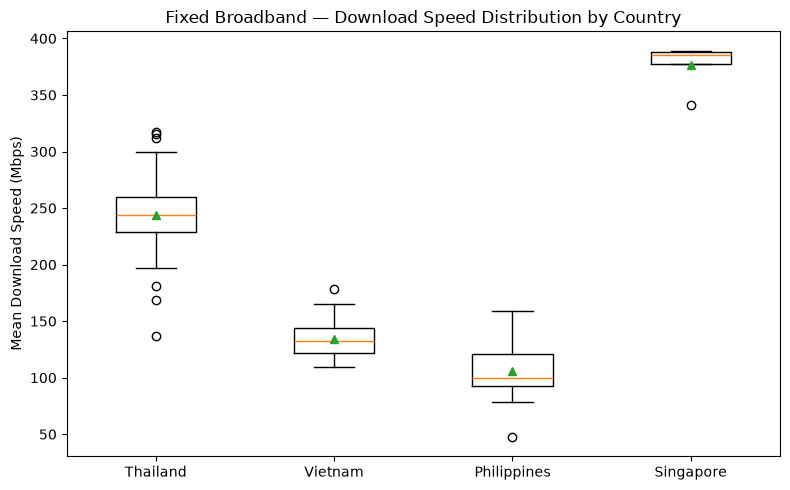

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ['Thailand', 'Vietnam', 'Philippines', 'Singapore']
data = [province_avg[province_avg['country'] == c]['mean_dl'].values for c in order]
ax.boxplot(data, tick_labels=order, showmeans=True)
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband — Download Speed Distribution by Country')
plt.tight_layout()
plt.show()

### 5. Statistical Test — Does Country Explain Speed Differences?

Kruskal-Wallis (non-parametric ANOVA) across the four country groups — avoids assuming normality with such small n for Singapore (5) and Philippines (17).

In [6]:
groups = [province_avg[province_avg['country'] == c]['mean_dl'].values for c in order]
h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={h_stat:.3f}, p={p_val:.4g}")
print("=> country group differences are statistically significant" if p_val < 0.05 else "=> no significant difference across countries")

Kruskal-Wallis H=127.759, p=1.644e-27
=> country group differences are statistically significant


### 6. Pairwise Comparison vs Thailand

Mann-Whitney U, Thailand vs each neighbor individually — which country(ies) actually differ from Thailand, not just "some country differs."

In [7]:
th = province_avg[province_avg['country'] == 'Thailand']['mean_dl']
for c in ['Vietnam', 'Philippines', 'Singapore']:
    other = province_avg[province_avg['country'] == c]['mean_dl']
    u_stat, p = stats.mannwhitneyu(th, other, alternative='two-sided')
    direction = 'higher' if th.mean() > other.mean() else 'lower'
    print(f"Thailand vs {c:12s}: TH mean={th.mean():6.1f}  {c} mean={other.mean():6.1f}  "
          f"p={p:.4g}  (Thailand {direction})")

Thailand vs Vietnam     : TH mean= 244.2  Vietnam mean= 134.6  p=6.401e-24  (Thailand higher)
Thailand vs Philippines : TH mean= 244.2  Philippines mean= 106.1  p=1.506e-10  (Thailand higher)
Thailand vs Singapore   : TH mean= 244.2  Singapore mean= 376.3  p=7.33e-08  (Thailand lower)


### 7. Cross-Country Regression — Country Effect After Controlling for GDP/Density

Does Thailand differ from its neighbors *because* of GDP/density context, or does a country-specific effect remain even after controlling for it?

In [8]:
model_df = province_avg.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

model = smf.ols('mean_dl ~ log_gdp + log_density + C(country, Treatment(reference="Thailand"))', data=model_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     612.9
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          2.13e-153
Time:                        19:24:08   Log-Likelihood:                -1006.9
No. Observations:                 236   AIC:                             2034.
Df Residuals:                     226   BIC:                             2069.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### 8. Summary Table — Country-Level Fixed Broadband Snapshot

In [9]:
summary = province_avg.groupby('country').agg(
    n_provinces=('province', 'count'),
    mean_dl=('mean_dl', 'mean'),
    median_dl=('mean_dl', 'median'),
    mean_ul=('mean_ul', 'mean'),
    mean_lat=('mean_lat', 'mean'),
).round(1).reindex(order)
summary

,n_provinces,mean_dl,median_dl,mean_ul,mean_lat
country,,,,,
Thailand,77,244.2,243.8,207.2,11.3
Vietnam,64,134.6,132.3,114.6,8.0
Philippines,17,106.1,99.7,98.6,21.5
Singapore,5,376.3,385.3,308.4,5.3


---
# Part 2 — Mobile/Cellular

### 9. Load, Filter, Collapse — Same Pipeline as Fixed

In [10]:
mobile = pd.concat([load_country(p, c) for c, p in COUNTRY_FILES_MOBILE.items()], ignore_index=True)
mobile_r = mobile[mobile['is_reliable']].copy()

mobile_avg = (
    mobile_r.groupby(['country', 'province'], as_index=False)
    .agg(mean_dl=('avg_d_mbps', 'mean'),
         mean_ul=('avg_u_mbps', 'mean'),
         mean_lat=('avg_lat_ms_wt', 'mean'),
         region=('region', 'first'),
         internet_tier=('internet_tier', 'first'),
         gdp_per_capita_thb_2021=('gdp_per_capita_thb_2021', 'first'),
         density_per_km2=('density_per_km2', 'first'))
)
print(f"Mobile — before filter: {len(mobile)} | after: {len(mobile_r)}")
mobile_avg.groupby('country')['mean_dl'].describe()[['count','mean','std','min','max']]

Mobile — before filter: 2776 | after: 2776


,count,mean,std,min,max
country,,,,,
Cambodia,25.0,32.812463,4.927589,25.332388,45.660465
Laos,18.0,39.099602,9.705313,30.939699,72.074515
Malaysia,16.0,170.851336,24.760064,140.968133,248.006436
Myanmar,14.0,25.580757,5.231190,18.799269,35.943931
Philippines,17.0,56.613967,17.276889,22.621783,100.973404
Singapore,5.0,193.606751,15.106492,172.090540,212.091854
Thailand,77.0,72.493660,14.793474,53.568646,124.913533
Vietnam,64.0,89.722304,15.330816,42.245413,133.293121


### 10. Distribution Comparison — Mobile Download Speed by Country

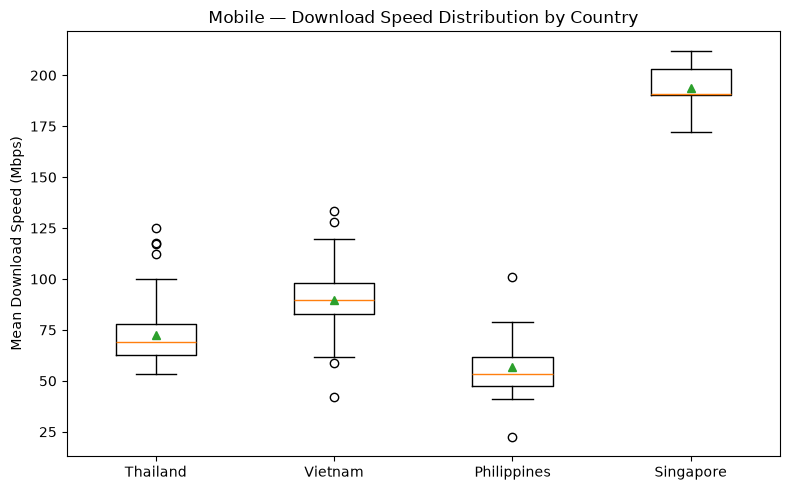

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
data_m = [mobile_avg[mobile_avg['country'] == c]['mean_dl'].values for c in order]
ax.boxplot(data_m, tick_labels=order, showmeans=True)
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title('Mobile — Download Speed Distribution by Country')
plt.tight_layout()
plt.show()

### 11. Statistical Test — Mobile

In [12]:
groups_m = [mobile_avg[mobile_avg['country'] == c]['mean_dl'].values for c in order]
h_stat_m, p_val_m = stats.kruskal(*groups_m)
print(f"Kruskal-Wallis H={h_stat_m:.3f}, p={p_val_m:.4g}")
print("=> country group differences are statistically significant" if p_val_m < 0.05 else "=> no significant difference across countries")

Kruskal-Wallis H=71.285, p=2.265e-15
=> country group differences are statistically significant


### 12. Fixed vs Mobile Gap, by Country

Thailand's public ranking is #13 fixed but only #39 mobile — check whether that fixed/mobile divergence shows up in this data too, and whether it's Thailand-specific or common across SEA.

In [13]:
gap = pd.DataFrame({
    'fixed_mean_dl': province_avg.groupby('country')['mean_dl'].mean(),
    'mobile_mean_dl': mobile_avg.groupby('country')['mean_dl'].mean(),
}).reindex(order)
gap['fixed_minus_mobile'] = gap['fixed_mean_dl'] - gap['mobile_mean_dl']
gap['fixed_mobile_ratio'] = gap['fixed_mean_dl'] / gap['mobile_mean_dl']
gap.round(1)

,fixed_mean_dl,mobile_mean_dl,fixed_minus_mobile,fixed_mobile_ratio
country,,,,
Thailand,244.2,72.5,171.7,3.4
Vietnam,134.6,89.7,44.9,1.5
Philippines,106.1,56.6,49.5,1.9
Singapore,376.3,193.6,182.7,1.9


## Key Findings Summary

- **Fixed broadband ranking (mean DL Mbps):** Singapore 376.3 > Thailand 244.2 > Vietnam 134.6 > Philippines 106.1. Kruskal-Wallis H=127.8, p=1.6e-27 — country differences are highly significant, not noise.
- **Pairwise vs Thailand (Mann-Whitney):** Thailand is significantly faster than Vietnam (p=6.4e-24) and Philippines (p=1.5e-10), and significantly slower than Singapore (p=7.3e-8). Thailand sits clearly in the middle of the pack, not top or bottom.
- **Cross-country OLS (mean_dl ~ log_gdp + log_density + country, Thailand as reference), R²=0.924:** after controlling for GDP and density, large country fixed-effects remain and are all significant — Philippines −135 Mbps, Vietnam −110 Mbps, Singapore +63 Mbps relative to Thailand. GDP and density are also independently significant (+15.2 and +9.3 Mbps per log-unit). **So the gap between countries is NOT fully explained by socioeconomic context** — something country-specific (infrastructure investment, ISP market structure, regulatory environment) remains after accounting for wealth and density.
- **Mobile:** Kruskal-Wallis H=71.3, p=2.3e-15 — also significant. Ranking flips for part of the pack: Singapore 193.6 > Vietnam 89.7 > Thailand 72.5 > Philippines 56.6. **Vietnam's mobile mean beats Thailand's**, even though Thailand's fixed mean beats Vietnam's by ~110 Mbps.
- **Fixed/mobile ratio by country:** Thailand 3.4 (much higher than Vietnam 1.5, Philippines 1.9, Singapore 1.9). This is the clearest empirical match to the real-world discrepancy cited in the paper's intro (Thailand fixed ranked #13 globally, mobile only #39) — Thailand's fixed and mobile networks are unusually far apart in quality relative to its SEA neighbors, where the two track each other more closely.
